# 07 · Did the regional campaign work? — synthetic control ⭐ (Anchor B)

**The business decision.** We ran a TV campaign in one metro area — a **DMA** (*Designated Market
Area*, the standard US media-buying region) — and left the rest of the country dark. Sales in that
metro are up since launch. Before we spend to roll the campaign out nationally: **was the lift caused
by the campaign, or would sales have risen there anyway?**

### Why this is hard: there was no control group

Unlike the uplift notebook (01), here there is **no randomized hold-out** — we didn't flip a coin to
decide which metro got the campaign, we just picked one. So we can't simply compare it to "the others."
And we can't just compare the treated metro's sales *after* vs *before*, because sales everywhere are
pushed around by a shared **trend** (secular growth), **seasonality**, and a common **macro wave**
(the economy, category demand). A naive before/after would credit the campaign with an uplift the
market would have delivered on its own. We need the one thing we can never observe: **what sales in
that metro *would have been* if we had not run the campaign** — its *counterfactual*.

### The idea: build the counterfactual from the other markets

**Synthetic control** (Abadie & Gardeazabal, 2003) constructs that missing counterfactual as a
**weighted blend of the untreated markets** — the "**donor pool**." It searches for a set of weights
so that the blend closely tracks the treated market's sales *in the pre-launch period*. If a weighted
combination of, say, 60% Denver + 25% Phoenix + 15% others matched our metro week-for-week *before*
the campaign, then — assuming those markets keep moving together — that same blend is our best guess
of what our metro *would* have done *after*, absent the campaign. The **gap** between the metro's
actual sales and this "synthetic" version, after launch, is the estimated lift.

The reason it can work at all: all markets share the same underlying **factors** (trend, season,
macro). A blend of donors that matches the treated unit's pre-period is, in effect, matching it on
those shared factors — so the blend and the treated unit stay locked together *unless something (the
campaign) breaks them apart*.

We do this the Bayesian way, so instead of one number we get a **posterior** — a full distribution of
plausible lifts — which gives us honest uncertainty, a real significance test (a **placebo
permutation**, defined in Depth B), and robustness checks a VP of Growth can interrogate before
committing national budget.

### How this notebook is organised

The **7-step contract** (question · simulate a known truth · identify · estimate · validate · decide
in € · caveats) plus the full **three depths**:

- **Depth A** — why the tempting naive estimators fail (a bake-off)
- **Depth B** — placebo inference in *space* and *time*, with the scale-free Abadie RMSE-ratio test
- **Depth C** — the euro rollout decision and its sensitivity to assumptions


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 3
CAMPAIGN_COST = 300.0            # €300k campaign cost (sales in €000)
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
print(f"FAST={FAST}  SC sampling={SC}")

FAST=True  SC sampling={'draws': 600, 'tune': 600, 'chains': 2}


## 2 · Simulate a ground truth (why fake data first)

As in every notebook here, we **cannot grade a causal method on real data** — the counterfactual
("what our metro would have done without the campaign") is never observed. So we build a simulator
where we *plant* the true lift, confirm the method recovers it, and only then trust it.

The simulator produces a weekly **sales panel**: a table with one row per market per week, for 30
DMAs over 60 weeks. Each market's sales are built from **shared latent factors** — a rising trend, a
seasonal cycle, and a random macro wave common to all markets — combined with that market's own
baseline level, its own sensitivity to each factor ("factor loadings"), and idiosyncratic noise. The
campaign launches in **week 40** in market 0 only, adding a **true +12% lift** from then on.

The shared macro wave is the villain: it moves *every* market together, so it's exactly what a naive
before/after would mistake for campaign effect. But it's also the hero of the method — because the
factors are *shared*, a weighted blend of the *other* markets can reconstruct market 0's untreated
path. That is precisely what makes the effect *identifiable* here (recoverable in principle), and the
plot below shows the setup: one dark line (treated) inside a bundle of grey donors, all riding the
same wave.

**The data-generating model** — exactly what `dgp.geo_panel` implements (defaults & seed in
`src/cmp/dgp.py`). Markets $i = 0,\dots,29$, weeks $t = 0,\dots,59$. Three **shared latent
factors**:

$$
\begin{aligned}
g_t &= 0.4\,t &&(\text{trend}),\\
s_t &= 8\sin\!\big(\tfrac{2\pi t}{26}\big) + 4\sin\!\big(\tfrac{2\pi t}{13}\big) &&(\text{season}),\\
m_t &= \sum_{u \le t} \eta_u,\;\; \eta_u \sim \mathcal N(0,\, 1.2^{2}) &&(\text{macro random walk}).
\end{aligned}
$$

Each market has its own baseline $c_i \sim U(80, 140)$ and factor loadings
$\lambda_{i} = (\lambda_{i1}, \lambda_{i2}, \lambda_{i3})$, each $\sim U(0.6, 1.4)$:

$$
Y_{it} = c_i + \lambda_{i1}\, g_t + \lambda_{i2}\, s_t + \lambda_{i3}\, m_t + \varepsilon_{it},
\qquad \varepsilon_{it} \sim \mathcal N(0,\, 3^{2}),
$$

and the campaign adds a **proportional lift to market 0 only**, from week 40:

$$
Y_{0t} = c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t + \varepsilon_{0t}
  + \Delta_t, \qquad
\Delta_t = 0.12\,\big(c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t\big)\,
  \mathbf 1[t \ge 40].
$$

This factor structure is precisely why synthetic control works here: every market rides the *same*
$(g_t, s_t, m_t)$, only with different loadings, so a convex combination of donors whose blended
loadings match $(\lambda_{01}, \lambda_{02}, \lambda_{03})$ reproduces market 0's untreated path.
It's also why the naive estimators fail — the random-walk $m_t$ moves all markets together, and a
before/after comparison books that shared drift as "lift."


Treated: dma_00, launch week 40.  TRUE lift €17.0k/week, total €339k.


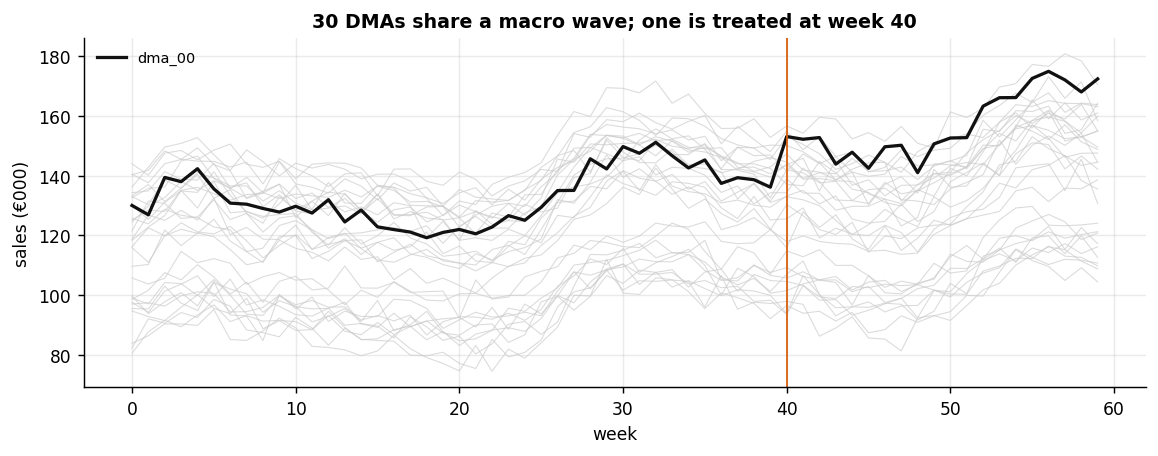

In [2]:
sales_df, true_effect, launch, treated_label = dgp.geo_panel(
    n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=SEED)
W = sales_df.shape[0]
sales = sales_df.values.T                        # (n_dmas, n_weeks)
treated_idx = list(sales_df.columns).index(treated_label)
pre, post = slice(0, launch), slice(launch, W)
t = np.arange(W)
true_total = float(true_effect[post].sum()); true_avg = float(true_effect[post].mean())

fig, ax = plt.subplots(figsize=(9, 3.6))
for j in range(sales.shape[0]):
    ax.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
ax.plot(t, sales[treated_idx], color="#111", lw=1.8, label=treated_label)
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.set_title("30 DMAs share a macro wave; one is treated at week 40")
ax.set_xlabel("week"); ax.set_ylabel("sales (€000)"); ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"Treated: {treated_label}, launch week {launch}.  TRUE lift €{true_avg:.1f}k/week, total €{true_total:.0f}k.")

## 3 · Identify — the estimand and the assumptions it rests on

**The estimand (the precise thing we *want*).** For each post-launch week $t$, the causal effect on the
treated market is the potential-outcome contrast

$$\tau_t \;=\; Y_{0,t}(1) \;-\; Y_{0,t}(0), \qquad t > T_0,$$

where $Y_{0,t}(1)$ is **observed** (the campaign ran) but $Y_{0,t}(0)$ — what week-$t$ sales *would have
been* with no campaign — is the **missing counterfactual**. (Throughout we label the treated unit **market 0** — matching §2's DGP and §4's fit — so the subscript is a *unit* index, not a treatment flag.)

**The estimator.** Synthetic control fills in that counterfactual with a weighted average of donor
markets, so the effect we actually compute is

$$\hat\tau_t \;=\; Y_{0,t} \;-\; \underbrace{\textstyle\sum_j w_j\, Y_{j,t}}_{\widehat{Y_{0,t}(0)}\ =\ \text{synthetic control}},
\qquad t > T_0,$$

where $Y_{0,t}$ is the **treated** market's sales in week $t$, $Y_{j,t}$ is **donor** market $j$'s
sales, $T_0$ is the launch week, and $w_j$ are the **donor weights**. The weights are chosen to match
the treated market's *pre-launch* path and are constrained to the **simplex**: each $w_j \ge 0$ and
they sum to 1 ($\sum_j w_j = 1$). Think of the simplex constraint as "the synthetic market must be a
genuine *weighted average* of real markets" — no negative weights, no scaling beyond the observed
range.

**Why the simplex matters (the core of Abadie's method).** If instead we let weights be any numbers
(ordinary regression), the "synthetic" market could sit *outside* the range of any real market —
**extrapolation** dressed up as a match, which fits the pre-period beautifully and then diverges wildly
after. Forcing weights onto the simplex keeps the synthetic inside the **convex hull** of the donors
(loosely, "inside the cloud of real markets"), which is what makes the post-launch projection credible.

**The assumptions — each gets an explicit check later:**

| assumption | plain meaning | checked in |
|---|---|---|
| **convex hull / no extrapolation** | the treated market lies inside the donor cloud; simplex weights enforce it | weights (Step 4) |
| **good pre-fit** | the synthetic actually tracks the treated market *before* launch | pre-RMSE gate (Step 5) |
| **no anticipation** | nothing shifts sales *before* launch (no leaked campaign, no pre-buying) | placebo-in-time (Depth B) |
| **stable factor structure** | donors and treated keep co-moving *after* launch (the loadings matched pre-launch still hold) | long pre-period + placebo-in-time |
| **no spillover / interference** | the campaign in market 0 doesn't change donor markets (SUTVA — the Stable Unit Treatment Value Assumption — for geos) | stress-tested by simulation (Depth B): planted spillover *attenuates* the estimate, and excluding the contaminated donors restores it — placebo-in-space *cannot* detect spillover (it contaminates every placebo too), so on real data exclude adjacent / media-overlapping donors up front |
| **no concurrent treated shock** | nothing else hit market 0 exactly at launch | untestable — institutional knowledge only |


## 4 · Estimate — a Bayesian synthetic control

We put a **Dirichlet prior** on the donor weights and fit them to the pre-period. (The *Dirichlet* is
the natural probability distribution over the simplex — draws from it are automatically non-negative
and sum to 1 — so it's the Bayesian way to say "the weights live on the simplex.") Fitting returns a
**posterior** over the weights, and therefore a posterior over the whole counterfactual path and the
lift — Abadie's constrained least squares, but with uncertainty for free.

**The fitted model, in symbols.** With $Y_{0t}$ the treated market and $Y_{jt}$ the $J = 29$
donors, fit **on the pre-period only** ($t < 40$):

$$
Y_{0t} \sim \mathcal N\Big(\textstyle\sum_{j=1}^{J} w_j\, Y_{jt},\;\; \sigma^{2}\Big), \qquad
w \sim \text{Dirichlet}(\mathbf 1_J), \qquad \sigma \sim \text{HalfNormal}(5).
$$

$\text{Dirichlet}(\mathbf 1_J)$ is flat over the simplex — no donor favoured a priori, weights
non-negative and summing to 1 by construction. The $\sigma \sim \text{HalfNormal}(5)$ scale is
likewise tied to the units of the data: sales are in €000s, weekly levels sit around €80–170k, and
the DGP's idiosyncratic noise has sd €3k — so a prior sd scale of €5k is weakly informative on the
residual: wide enough to cover any plausible blend error, tight enough to rule out absurd ones (a
€50k weekly residual would mean the "synthetic" tracks nothing). The counterfactual for *every* week is then the
posterior-predictive blend $\hat Y_{0t}^{(0)} = \sum_j w_j Y_{jt} + \varepsilon_t$ with
$\varepsilon_t \sim \mathcal N(0, \sigma^{2})$ — the $\varepsilon_t$ matters: dropping it (using
the mean blend alone) understates the uncertainty band, which is exactly the coverage lesson step
5 quantifies — and the weekly lift is $Y_{0t} - \hat Y_{0t}^{(0)}$.

Two things to read off the fit:
- **Which donors** the synthetic leans on (the weight bars). One caveat to state plainly: the Dirichlet
  prior produces a *regularized blend* spread over many donors, rather than classical synthetic
  control's sparse handful. That's **more stable** out-of-sample but **less individually interpretable**.
  We summarise the spread as an **"effective number of donors"** = $1/\sum_j w_j^2$ (the inverse
  Herfindahl index — 1 if all weight is on one donor, $J$ if spread evenly over $J$ donors).
- **Pre-fit RMSE** — the root-mean-square gap between the treated market and its synthetic *before*
  launch, in €000. Small means the synthetic is a good stand-in; this is the precondition for believing
  the post-launch gap — Step 5 turns this into a concrete PASS/FAIL gate (pre-RMSE below ~a third of the weekly lift it must detect).

**Reading the sampler's health check.** The `convergence` line printed below reports the three standard MCMC health checks — the numbers that say whether the sampler (the algorithm that draws from the posterior) actually converged. **R-hat** compares the variance within each chain to the variance across chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or interval. **Divergences** are steps where the sampler broke down and silently distrusts that region; **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short (2 chains), so R-hat can sit a hair over the 1.01 line and PyMC may print a "problems during sampling" notice — a benign artifact of the small draw count, not a red flag: the ESS below is in the healthy hundreds and divergences are 0, so the flagship fit is sound.

> **On real data.** You don't need our simulator — this method runs on *your own* weekly (or daily)
> sales-by-market panel, which every company already has: one treated market, the rest as donors. The
> canonical *public* example is Abadie's **California Proposition 99** tobacco study (California vs 38
> other US states); it has the identical shape (one treated unit, many donors, a known intervention
> date) and is the standard dataset to reproduce this on.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [w, sd]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


SC sampling convergence: max r-hat 1.010 - min ESS 836 - divergences 0
pre-fit RMSE €2.86k  ·  estimated total lift €305k (true €339k)  ·  90% CI [€272k, €342k] — at full precision the truth sits inside this band (§5's multi-seed check explains why the total-lift band runs optimistic)


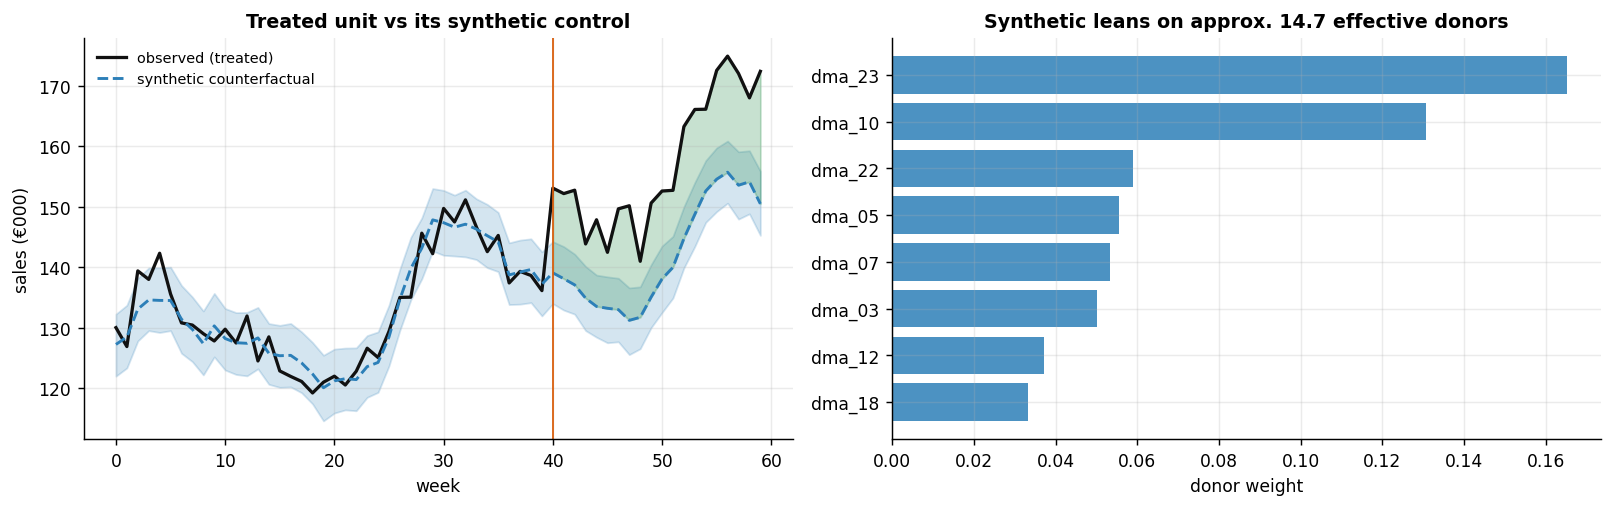

In [3]:
donors = np.delete(sales, treated_idx, axis=0)
donor_labels = [c for c in sales_df.columns if c != treated_label]
y_tr = sales[treated_idx]

sc = est.synthetic_control(y_tr, donors, pre, post, seed=1, **SC)
print(f"SC sampling convergence: {sc['convergence']['summary']}")
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1)
w_mean = sc["weight_samples"].mean(0)
eff_n = 1.0 / np.sum(w_mean**2)               # effective number of donors (inverse HHI)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch, xlabel="week", ylabel="sales (€000)")
topw = np.argsort(-w_mean)[:8]
ax[1].barh([donor_labels[i] for i in topw][::-1], w_mean[topw][::-1], color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on approx. {eff_n:.1f} effective donors")
fig.tight_layout()
lo_t, hi_t = np.quantile(total_post, [0.05, 0.95])
print(f"pre-fit RMSE €{sc['pre_rmse']:.2f}k  ·  estimated total lift €{total_post.mean():.0f}k "
      f"(true €{true_total:.0f}k)  ·  90% CI [€{lo_t:.0f}k, €{hi_t:.0f}k] — at full precision the truth "
      f"sits {'inside' if lo_t <= true_total <= hi_t else 'just OUTSIDE'} this band "
      f"(§5's multi-seed check explains why the total-lift band runs optimistic)")

## 5 · Validate — recovery, calibration, the pre-fit gate, and robustness

Four checks — and one of them delivers a genuinely humbling result we keep rather than hide:

1. **Recovery & calibration.** The true per-week path should sit inside the posterior band. That
   band is a **posterior predictive**: it carries not only *which-donors* (weight) uncertainty but
   the treated market's own idiosyncratic noise. That noise term is what makes the per-week band
   near-nominal; a weights-only band is too narrow and can leave the truth *outside* a "90%" interval.
2. **Multi-seed calibration.** One panel is a single draw of the world, so we refit on fresh panels
   and report the recovery bias and coverage. The honest result: the **per-week** band is near-nominal,
   but the **total-lift** interval covers well *below* nominal — synthetic control's genuine
   sample-to-sample variance is larger than any single panel's posterior width. So the posterior
   interval is an *optimistic* guide to the total, and the trustworthy inference is the **placebo
   permutation test** (design-based, calibrated by construction), not the band. This is *why* the
   euro call below is "confirm with a second test," not "the interval says go." *(The per-seed refits in this check are deliberately coarse 300-draw probes, read only in aggregate; their sampler chatter is silenced.)*
3. **Pre-fit gate** — the pre-period gap must hover around **zero**: concretely, pre-RMSE below about a
   third of the weekly lift the design must detect (printed as an explicit PASS/FAIL below). A bad synthetic
   match makes the post gap meaningless — this is the precondition, not a formality.
4. **Leave-one-out donor robustness** — drop each of the top-weighted donors and refit; if the
   estimate lurches when one donor leaves, the result hangs on a single market and is fragile.

   These leave-one-out refits — and every robustness check from here on (placebo, spillover, launch-date sweep) — use the **SLSQP fitter**: the classical, *non-Bayesian* synthetic control. It is a deterministic constrained-least-squares solve (SLSQP is `scipy`'s *Sequential Least-Squares Quadratic Programming* optimizer — the routine that finds the simplex donor weights), with no MCMC, so it runs in milliseconds and returns a **point estimate only**, no uncertainty band. We benchmark each dropped-donor bar against that *same* fitter's own all-donor baseline (the grey line) so the comparison is apples-to-apples; that SLSQP baseline runs a touch tighter than the Bayesian fit because the Dirichlet prior lightly regularizes the blend — which is why the plot labels “all donors (SLSQP)” and “all donors (Bayesian)” as two nearby-but-distinct numbers.

pre-fit gate: pre-RMSE €2.86k  vs  |weekly lift|/3 = €5.1k  ->  PASS
pre-launch gap mean €0.34k (≈0 = good fit).  LOO total range €309–337k vs the same-fitter SLSQP baseline €318k (Bayesian €305k) — no single donor drives it.


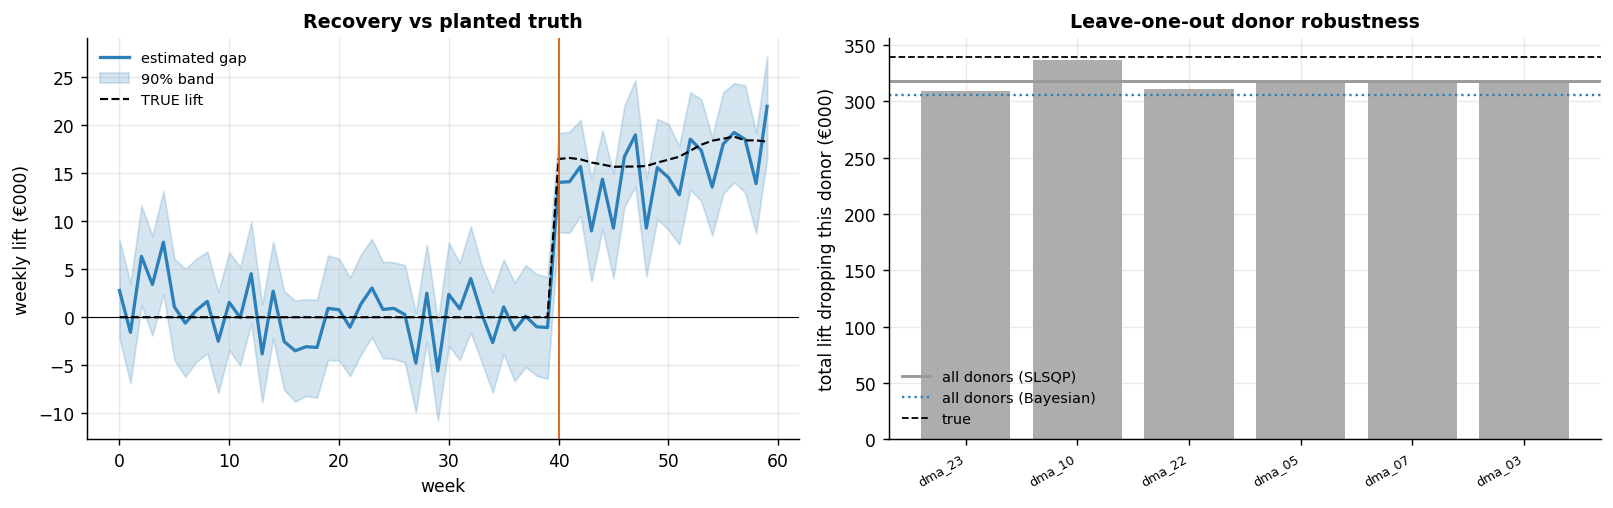

In [4]:
eff_mean = effect.mean(0); eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo, eff_hi, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].plot(t, true_effect, color="k", ls="--", lw=1.2, label="TRUE lift")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("week"); ax[0].set_ylabel("weekly lift (€000)"); ax[0].set_title("Recovery vs planted truth")
ax[0].legend(frameon=False, fontsize=8)

# leave-one-out: drop each top donor, refit with the fast SLSQP fitter
loo = []
for i in topw[:6]:
    keep = [k for k in range(donors.shape[0]) if k != i]
    gap, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gap[post].sum())
full_total = eff_mean[post].sum()
slsqp_full, _ = est.sc_effect_slsqp(y_tr, donors, pre, post)   # same-fitter (SLSQP) baseline for the LOO bars
slsqp_full_total = slsqp_full[post].sum()
ax[1].axhline(slsqp_full_total, color=plots.GREY, lw=1.6, label="all donors (SLSQP)")
ax[1].axhline(full_total, color=plots.BLUE, ls=":", lw=1.3, label="all donors (Bayesian)")
ax[1].axhline(true_total, color="k", ls="--", lw=1, label="true")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo))); ax[1].set_xticklabels([donor_labels[i] for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor (€000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()
# Pre-fit gate, made concrete: pre-RMSE must be small RELATIVE TO the weekly lift it must detect
# (a non-oracle scale — uses the estimated lift, not the planted truth).
n_post = np.zeros(len(t))[post].size
weekly_lift = total_post.mean() / n_post
gate_ref = abs(weekly_lift) / 3
gate = "PASS" if sc["pre_rmse"] < gate_ref else "FAIL"
print(f"pre-fit gate: pre-RMSE €{sc['pre_rmse']:.2f}k  vs  |weekly lift|/3 = €{gate_ref:.1f}k  ->  {gate}")
print(f"pre-launch gap mean €{eff_mean[pre].mean():.2f}k (≈0 = good fit).  "
      f"LOO total range €{min(loo):.0f}–{max(loo):.0f}k vs the same-fitter SLSQP baseline €{slsqp_full_total:.0f}k "
      f"(Bayesian €{full_total:.0f}k) — no single donor drives it.")

In [5]:
# Multi-seed recovery + calibration. One panel is a single draw of the world, so we refit on
# fresh panels and report (a) the recovery bias, (b) how often the PER-WEEK band covers the
# true path, and (c) how often the TOTAL-lift 90% interval covers the planted total. The gap
# between (b) and (c) is the honest lesson.
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
rows = []
for s in range(10 if FAST else 24):
    sd_, te_, _lz, tl_ = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=100 + s)
    sl = sd_.values.T; ti = list(sd_.columns).index(tl_)
    scs = est.synthetic_control(sl[ti], np.delete(sl, ti, axis=0), pre, post, seed=1, **{**SC, 'draws': 300, 'tune': 300})
    eff = scs['effect_samples']; tot = eff[:, post].sum(1); truth = float(te_[post].sum())
    lo, hi = np.quantile(tot, [.05, .95]); elo, ehi = np.quantile(eff, [.05, .95], 0)
    rows.append({'err': tot.mean() - truth, 'true': truth, 'tot_cov': lo <= truth <= hi,
                 'tot_sd': tot.std(),   # what the posterior BELIEVES the total's sd is (used below)
                 'wk_cov': np.mean((elo[post] <= te_[post]) & (te_[post] <= ehi[post]))})
ms = pd.DataFrame(rows)
print(f"Across {len(ms)} fresh panels — recovery bias €{ms.err.mean():+.0f}k "
      f"({ms.err.mean()/ms['true'].mean():+.0%}), with a LARGE seed-to-seed sd of €{ms.err.std():.0f}k.")
print(f"PER-WEEK band covers the true path {ms.wk_cov.mean():.0%} of the time — ≈ nominal; the "
      f"posterior-predictive obs-noise term earns this.")
print(f"But the TOTAL-lift 90% interval covers only ~{ms.tot_cov.mean():.0%} across panels: SC's "
      f"sample-to-sample variance dwarfs any single panel's posterior width, so the total interval is optimistic.")
print("=> the CALIBRATED inference is the placebo permutation test (below), not the posterior band alone.")
_pml.setLevel(_pml_lvl)

Across 10 fresh panels — recovery bias €+38k (+11%), with a LARGE seed-to-seed sd of €56k.
PER-WEEK band covers the true path 87% of the time — ≈ nominal; the posterior-predictive obs-noise term earns this.
But the TOTAL-lift 90% interval covers only ~40% across panels: SC's sample-to-sample variance dwarfs any single panel's posterior width, so the total interval is optimistic.
=> the CALIBRATED inference is the placebo permutation test (below), not the posterior band alone.


**Why does the total-lift band under-cover while the per-week bands are fine?** This is the
notebook's most important negative result, and it is not a mystery — it follows from one modelling
choice. The likelihood treats the weekly errors as independent, so if $e_t$ is the error of the
synthetic blend in week $t$, the model prices the uncertainty of the $n = 20$-week **total** as

$$\operatorname{sd}\Big(\sum_{t \in \text{post}} e_t\Big) \;=\; \sqrt{n}\,\sigma
\qquad \text{(iid errors)}.$$

But the blend's true error is *not* iid. Whatever part of the treated market's factor loadings the
weights fail to match leaks the shared factors straight into the gap,

$$e_t \;\approx\; \big(\lambda_0 - \textstyle\sum_j w_j \lambda_j\big)^{\!\top}
(g_t,\, s_t,\, m_t) \;+\; \varepsilon_{0t},$$

and $m_t$ is a **random walk** — so the mismatch term is a *persistent, slowly wandering offset*,
not fresh noise each week. For correlated errors the variance of a sum picks up all the covariance
terms,

$$\operatorname{Var}\Big(\sum_{t=1}^{n} e_t\Big)
\;=\; \sigma^2\Big(n \;+\; 2\sum_{k=1}^{n-1}(n-k)\,\rho_k\Big)
\;\xrightarrow{\;\rho_k \to 1\;}\; n^2\sigma^2 \;\gg\; n\,\sigma^2 ,$$

where $\rho_k$ is the error's lag-$k$ autocorrelation. **Per-week bands only need the marginal
variance** $\sigma^2$, which the posterior-predictive $\varepsilon_t$ term gets roughly right —
that is why they cover ≈ nominal. **The total needs the covariances too**, and the iid likelihood
sets every $\rho_k$ to zero. The cell below measures both faces of this on live data: the
*in-sample* pre-period residual shows only modest, sign-flipping autocorrelation (the fit **whitens** — scrubs the serial correlation out of — most of what it can see in-sample, which is why eyeballing the pre-fit residual would *not* warn you), while the
*out-of-sample* gap error — measured on placebo worlds where the true lift is zero, so the post
gap **is** the error — is almost perfectly persistent from week to week.

In [6]:
# Mechanism, measured — symptom, cause, size of the damage.
# (1) Size: compare the posterior's own sd for the 20-week total (what the band believes) with the
#     actual seed-to-seed sd of the total error from the multi-seed check above.
# (2) Cause: the in-sample pre-period residual of OUR fit vs the out-of-sample gap error on cheap
#     SLSQP placebo worlds (true lift = 0, so the post-period gap IS the error). Autocorrelations
#     are computed about zero — in a placebo world the error's true mean is zero, and demeaning a
#     20-week window would silently absorb exactly the persistent offset we are trying to expose.
# Pure numpy + the deterministic SLSQP fitter: no MCMC, runs in well under a second even in FAST.
sd_believed = ms.tot_sd.mean()             # what the posterior band thinks the total's sd is
sd_actual = ms.err.std()                   # what the world actually delivers, seed to seed
print(f"posterior sd of the 20-week total (mean across panels): €{sd_believed:.0f}k   vs   actual "
      f"seed-to-seed sd of the total error: €{sd_actual:.0f}k  ->  ~{sd_actual/sd_believed:.1f}x underestimated")

res_pre = eff_mean[pre] - eff_mean[pre].mean()          # in-sample residual: OUR fit's pre-period gap
acf_pre = [float(np.corrcoef(res_pre[:-k], res_pre[k:])[0, 1]) for k in (1, 2, 3)]
E = []                                                  # out-of-sample gap error, placebo worlds
for s in range(12 if FAST else 24):
    psd, _pte, _pl, ptl = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.0, seed=400 + s)
    psl = psd.values.T; pti = list(psd.columns).index(ptl)
    pgap, _ = est.sc_effect_slsqp(psl[pti], np.delete(psl, pti, axis=0), pre, post)
    E.append(pgap[post])
E = np.asarray(E)
rho = [float(np.mean(E[:, :-k] * E[:, k:]) / np.mean(E**2)) for k in (1, 2, 3, 5, 8)]
print(f"in-sample pre-period residual ACF (lags 1-3): {np.round(acf_pre, 2)} — modest and sign-flipping "
      f"(noise band ≈ ±{2/np.sqrt(res_pre.size):.2f}); the fit whitens most of what it can see")
print(f"out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1,2,3,5,8): {np.round(rho, 2)}")
print("Symptom: the total-lift band under-covers (above). Mechanism: the blend's")
print("error is a PERSISTENT offset — the unmatched share of the macro random walk —")
print("not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,")
print("not the n the iid likelihood charges for. Per-week bands only price the")
print("marginal variance, which is why they stay ≈ nominal while the total band is")
print("optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't")
print("mix — for totals, use design-based placebo inference (Depth B) or a")
print("likelihood with correlated (AR / random-walk) errors.")

posterior sd of the 20-week total (mean across panels): €24k   vs   actual seed-to-seed sd of the total error: €56k  ->  ~2.3x underestimated
in-sample pre-period residual ACF (lags 1-3): [-0.03  0.38 -0.12] — modest and sign-flipping (noise band ≈ ±0.32); the fit whitens most of what it can see
out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1,2,3,5,8): [0.94 0.94 0.93 0.95 0.95]
Symptom: the total-lift band under-covers (above). Mechanism: the blend's
error is a PERSISTENT offset — the unmatched share of the macro random walk —
not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,
not the n the iid likelihood charges for. Per-week bands only price the
marginal variance, which is why they stay ≈ nominal while the total band is
optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't
mix — for totals, use design-based placebo inference (Depth B) or a
likelihood with correlated (AR / random-walk) errors.


## 6 · Decide, in euros

The campaign cost **€300k**. Everything the notebook has produced so far now collapses into a
single object: the **posterior over total incremental sales** across the 20 post-launch weeks
(`total_post`, in €000). The rollout question is *not* "is the lift positive?" — Depth B's placebo
permutation answers that — but **"what is the probability the lift beats what we paid?"**, because
a real-but-too-small effect still loses money at national scale.

**The decision rule** (`policy.go_no_go`, the cookbook's standard): read
$P(\text{value} > \text{cost})$ off the posterior and act on a stated convention —

- $P > 0.9$ → **GO** — sure enough to act without buying more evidence;
- $P < 0.5$ → **NO-GO** — more likely than not the campaign doesn't pay at this price;
- in between → **TEST FURTHER** — the honest middle where the effect may well be real but the
  *economics* are not yet settled.

Alongside the probability it reports the expected **net value** ($\mathbb E[\text{value}] -
\text{cost}$, in €000) and the expected **ROI** as a ratio (net ÷ cost, so break-even is 0) —
three views of the same posterior, so nobody has to reverse-engineer the call from a chart.

**How to read the two panels.** *Left*: the posterior of total lift with the €300k cost line —
the mass to the right of the line **is** $P(\text{lift} > \text{cost})$ (the dashed marker is the
true total, which we only know because this is a simulation). *Right*: the same posterior read as
a **headroom curve** — sweep a hypothetical cost $c$ and plot $P(\text{lift} > c)$. Where the
curve crosses the green 0.9 line is the *highest price at which this evidence would already
justify a confident GO* — the number to bring to the media-buying negotiation, not just a yes/no.

{
  "P_value_gt_cost": 0.59,
  "expected_value": 305.28,
  "expected_net_value": 5.28,
  "expected_roi": 0.02,
  "value_lo": 272.42,
  "value_hi": 341.54,
  "cost": 300.0,
  "decision": "TEST FURTHER"
}


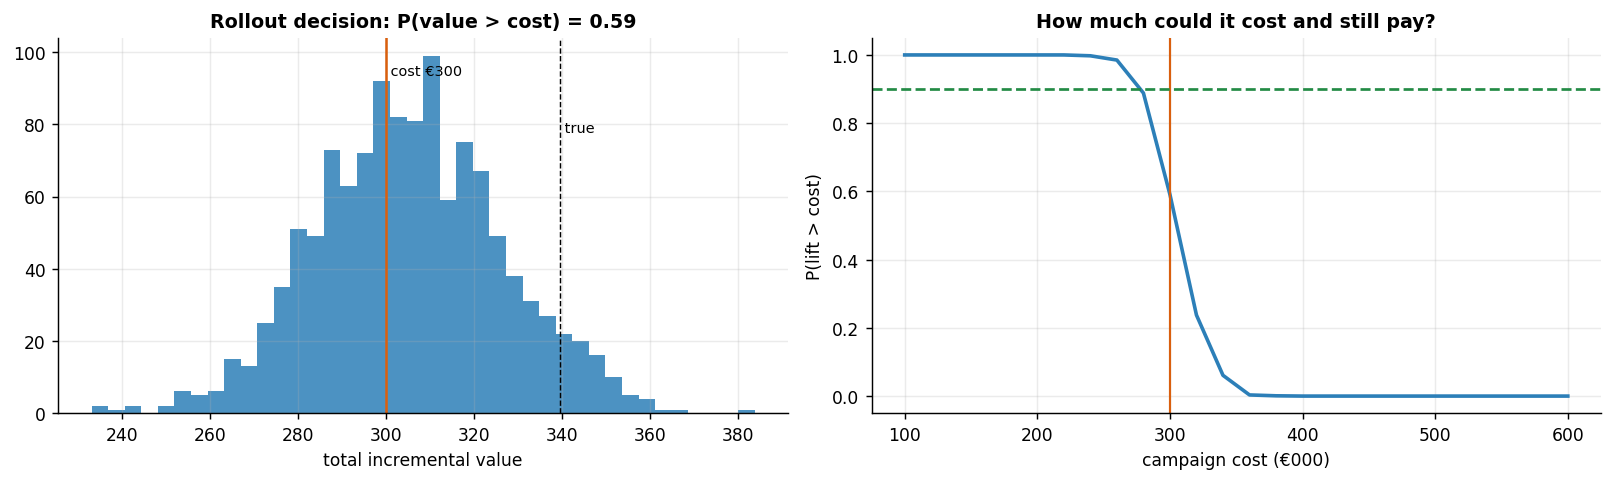

In [7]:
decision = policy.go_no_go(total_post, CAMPAIGN_COST)
cost_grid = np.linspace(100, 600, 26)
p_beats = [(total_post > c).mean() for c in cost_grid]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], total_post, CAMPAIGN_COST, true_total=true_total)
ax[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
ax[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2); ax[1].axhline(0.9, color=plots.GREEN, ls="--")
ax[1].set_xlabel("campaign cost (€000)"); ax[1].set_ylabel("P(lift > cost)"); ax[1].set_title("How much could it cost and still pay?")
fig.tight_layout()
def _round(x, nd=2):
    if isinstance(x, float): return round(x, nd)
    if isinstance(x, dict): return {k: _round(v, nd) for k, v in x.items()}
    if isinstance(x, list): return [_round(v, nd) for v in x]
    return x
print(json.dumps(_round(decision), indent=2))

**Read-out.** The verdict in this run is **TEST FURTHER**, and the JSON says exactly why: the
expected lift (≈ €305k) sits almost on top of the €300k cost — expected net value ≈ **€5k**, ROI
≈ **+2%** — and $P(\text{lift} > \text{cost}) \approx 0.59$, barely better than a coin flip.
Hold this against Depth B without flinching at the apparent contradiction: the placebo permutation
says the effect is **real** (p ≈ 0.03–0.05), while the economics say it is **marginal at this
price**. Both are true at once — "statistically significant" and "worth the money" are different
questions, and conflating them is how marginal campaigns get scaled. The headroom curve prices the
gap: the 0.9 crossing sits at ≈ €275k in this run, so had the campaign cost ~8% less, this same
evidence would already be a confident GO. At €300k, the evidence buys conviction that *something*
happened, not conviction that it *paid*.

**A borderline call has a price tag: the value of information.** "TEST FURTHER" must not end as a
shrug — the deliverable is an answer to *"what evidence would settle this, and is it worth
buying?"* Two tools, both computed below:

- **VOI (value of information).**
  $\text{VOI} = \mathbb E\big[\max(V - c,\, 0)\big] - \max\big(\mathbb E[V] - c,\, 0\big)$ — the
  expected gain from deciding *after* the uncertainty resolves versus committing now on the mean.
  Intuition: if the truth lands below the cost line, perfect foresight would have let us walk away
  and keep the difference; VOI is that averted loss, averaged over the posterior. It is the most a
  *perfectly informative* test could add in expected decision value — i.e. an **upper bound on any
  confirmatory-test budget**.
- **Test sizing.** A second geo test treating $k$ independent markets tightens the posterior
  roughly as $1/\sqrt{k}$ — it **sharpens** the estimate around the same mean; it doesn't move it.
  So "how big must the test be?" becomes: *the smallest $k$ whose tightened posterior reaches*
  $P(\text{lift} > \text{cost}) \ge 0.9$. Two hidden assumptions live inside that $1/\sqrt{k}$, and both
  flatter the test: it treats the $k$ market-level estimates as **independent** with equal
  variance — but this whole world is built on *shared* macro factors, so the $k$ gap estimates
  share estimation error and the *effective* $k$ is smaller than the nominal one — and it takes
  this posterior's sd as the per-market scale, which the multi-seed check just showed runs
  optimistic. Both push the same way: read the computed $k$ as a **lower bound**.

Value of information: resolving the cost-line uncertainty is worth ~€6k of expected decision value.
A confirmatory geo test averaging ~27 independent treated markets would tighten the interval
enough to reach P(lift>cost) >= 0.90 — and since the multi-seed check showed this interval is
*optimistic*, treat 27 as a LOWER bound on the test size. That is the experiment to run, not a blind launch.


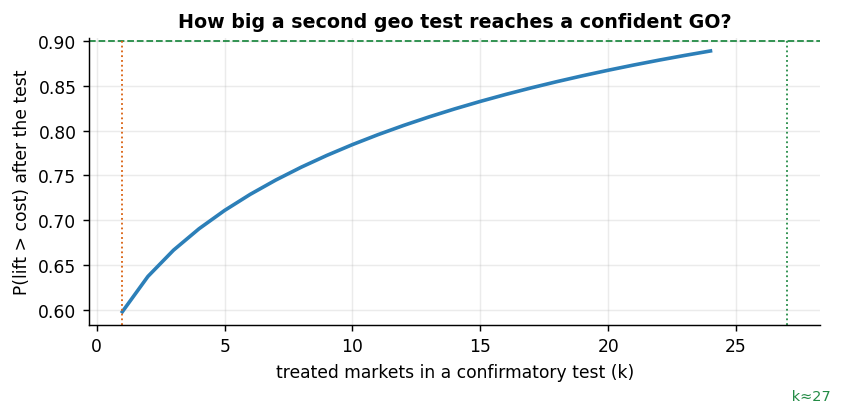

In [8]:
# Value of information & test-sizing: the decision is borderline, so what is a confirmatory geo test
# worth, and how big must it be? VOI = E[max(lift-cost,0)] - max(E[lift]-cost,0) is the expected value
# of resolving the "does it clear cost?" uncertainty before committing.
from scipy.stats import norm
voi = float(np.maximum(total_post - CAMPAIGN_COST, 0).mean() - max(total_post.mean() - CAMPAIGN_COST, 0))
mu, sdev = total_post.mean(), total_post.std()
# A second test averaging k independent treated markets tightens the estimate ~1/sqrt(k) (it sharpens,
# doesn't move it). Find the smallest k reaching a confident GO, P(lift>cost) >= 0.9.
def p_go(k): return float(1 - norm.cdf(CAMPAIGN_COST, loc=mu, scale=sdev / np.sqrt(k)))
k_needed = next((k for k in range(1, 60) if p_go(k) >= 0.9), None)
n_mkts = sales.shape[0]                       # how many markets this world even contains
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ks = np.arange(1, 25); ax.plot(ks, [p_go(k) for k in ks], color=plots.BLUE, lw=2)
ax.axhline(0.9, color=plots.GREEN, ls="--", lw=1); ax.axvline(1, color=plots.ORANGE, ls=":", lw=1)
if k_needed: ax.axvline(k_needed, color=plots.GREEN, ls=":", lw=1); ax.text(k_needed, 0.5, f" k≈{k_needed}", fontsize=8, color=plots.GREEN)
ax.set_xlabel("treated markets in a confirmatory test (k)"); ax.set_ylabel("P(lift > cost) after the test")
ax.set_title("How big a second geo test reaches a confident GO?"); fig.tight_layout()
print(f"Value of information: resolving the cost-line uncertainty is worth ~€{voi:.0f}k of expected decision value.")
if k_needed and k_needed <= n_mkts - 1:
    print(f"A confirmatory geo test averaging ~{k_needed} independent treated markets would tighten the interval\n"
          f"enough to reach P(lift>cost) >= 0.90 — and since the multi-seed check showed this interval is\n"
          f"*optimistic*, treat {k_needed} as a LOWER bound on the test size. That is the experiment to run, not a blind launch.")
elif k_needed:
    print(f"Reaching P(lift>cost) >= 0.90 would take ~{k_needed} independent treated markets — more than this\n"
          f"world contains ({n_mkts} DMAs, one already treated). The honest read: NO feasible single confirmatory\n"
          f"test gets to 0.90 here; extend the post-period, pool repeated tests, or accept a lower confidence bar —\n"
          f"and the multi-seed check says even this arithmetic is optimistic. Still an experiment, never a blind launch.")
else:
    print("Even a large confirmatory test would not reach 0.90 at this point estimate — the effect sits too close to cost.")

**Read-out — sizing the confirmatory test.** VOI ≈ **€6k** in this run: with the posterior centred almost exactly on the cost line, even perfect information barely changes the expected outcome — whichever way the truth falls, we're near break-even, so the *stakes of deciding wrong are small*. That immediately disciplines the next step: a confirmatory test is only rational if it costs less than ~€6k of all-in decision value — no €50k research program is justified by these economics. Now the sizing arithmetic, read straight off the cell above: reaching the 0.9 bar takes **the number of independent treated markets printed there**, and because the multi-seed check in step 5 showed the interval is *optimistic*, treat that count as a *lower* bound. Whether that many markets is even available — this world holds 30 DMAs, one already treated — is what decides the branch: if the required count fits inside the pool, **that confirmatory geo test is the experiment to run**; if it exceeds the pool, **no single geo test settles the question at this price**, and the fallbacks below take over. Those honest fallbacks hold either way: **renegotiate the price** (at ≈ €275k the existing evidence already clears 0.9), **extend the post-period or pool repeated tests** (more weeks per market buys precision too), or **accept a lower confidence bar** knowing the multi-seed check says these intervals are already optimistic. What is *not* on the list: a blind national rollout. Depth C pulls this thread together with the launch-date and donor-pool sensitivities into the one-paragraph verdict a VP signs.

## 7 · Caveats

- **Here synthetic control is high-variance, not conservative.** In this panel the point estimate lands
  ~10% low, but across seeds (Step 5) it shows only a small positive mean bias (single digits to low-teens % across seeds) but a *large* sample-to-sample spread — and
  its posterior interval is *optimistic* about the total lift. So trust the **placebo permutation test**,
  not the point estimate or the band — §5 shows the mechanism: the blend's error is a *persistent*
  (serially correlated) offset, so the iid likelihood underprices the variance of any multi-week total.
- **Pre-fit is a gate, not a formality.** High pre-RMSE ⇒ the post gap is uninterpretable; no
  Bayesian machinery fixes a bad donor pool.
- **No-anticipation and no-spillover are assumptions.** Anticipation is stress-tested by
  placebo-in-time in Depth B; spillover is *invisible to every placebo*, so Depth B stress-tests it
  by simulation instead — planted spillover **attenuates** the estimate (SC under-states, never
  inflates), and the fix is donor-pool design, not statistics.
- **One treated unit = limited power.** Significance comes from the permutation test, coarse
  with few donors.


---
# Depth A · Why the naive estimators fail

Two tempting shortcuts, both confounded by the shared trend/season/macro wave:

- **Before/after**: post mean − pre mean of the treated DMA — books the entire trend as effect.
- **Treated − average control**: the average control has the wrong factor loadings, so it
  doesn't cancel the common wave cleanly.

Synthetic control is the fix: a *weighted* control chosen to match pre-launch.


{
  "true": 17.0,
  "before/after": 24.3,
  "treated - avg ctrl": 27.1,
  "DiD vs avg ctrl": 14.5,
  "synthetic control": 15.3
}


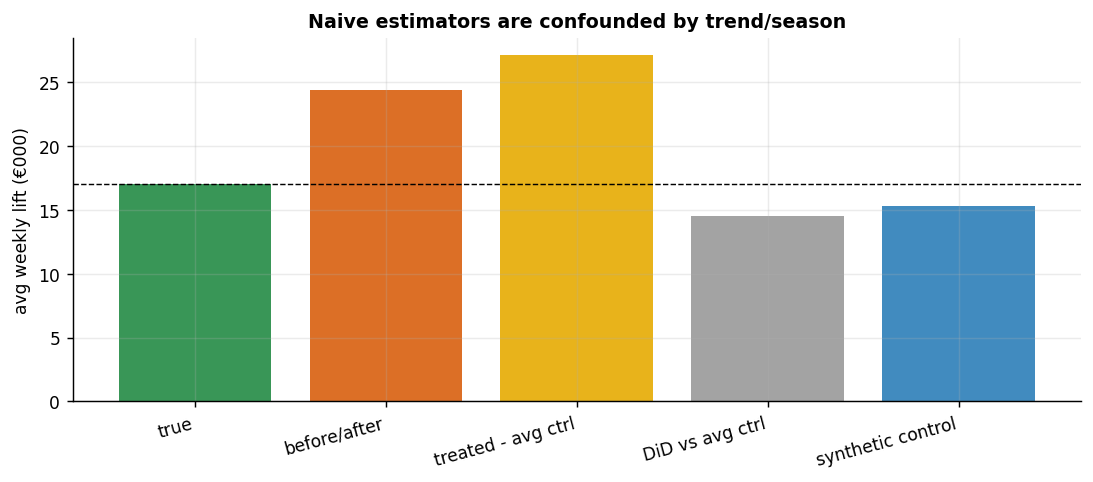

In [9]:
naive_prepost = y_tr[post].mean() - y_tr[pre].mean()
naive_avgctrl = (y_tr[post] - donors[:, post].mean(0)).mean()
# Difference-in-differences vs the average control: subtracts the shared pre-period level too, so it
# removes the trend the level-difference leaves in — isolating the *factor-loading* mismatch that only
# a reweighted synthetic can fix.
naive_did = ((y_tr[post] - donors[:, post].mean(0)).mean()
             - (y_tr[pre] - donors[:, pre].mean(0)).mean())
sc_avg = eff_mean[post].mean()
bake = {"true": true_avg, "before/after": float(naive_prepost),
        "treated - avg ctrl": float(naive_avgctrl), "DiD vs avg ctrl": float(naive_did),
        "synthetic control": float(sc_avg)}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.GREY, plots.BLUE]
ax.bar(list(bake.keys()), list(bake.values()), color=cols, alpha=0.9); ax.axhline(true_avg, color="k", ls="--", lw=0.8)
ax.set_ylabel("avg weekly lift (€000)"); ax.set_title("Naive estimators are confounded by trend/season")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.tight_layout()
print(json.dumps({k: round(v,1) for k,v in bake.items()}, indent=2))

**Read-out.** Before/after badly overstates the lift (it books the trend); treated-minus-average
is **worse** — it books the raw between-market level gap, differencing nothing out; differencing out the shared trend (DiD vs the average control) removes the
trend bias yet a *level* gap from mismatched factor loadings remains; **the reweighted synthetic control comes closest** (€15.3k vs the true €17.0k — about a 10% undershoot; DiD-vs-average lands at €14.5k, and neither naive shortcut is even close). Same data, four estimates — the
estimator *is* the identification strategy.


---
# Depth B · Placebo inference — is the gap statistically real?

We have a lift estimate, but with **one treated market** there's no classical standard error to test
it (standard errors assume many independent units). Instead we ask a **permutation** question, the
inferential heart of synthetic control:

> *If the campaign had no effect, how unusual would a post-launch gap this big be, just by chance?*

**Placebo-in-space.** We answer it by pretending, in turn, that *each donor market* was the treated
one: fit that donor its own synthetic control from the remaining donors, and record its post-launch
"gap." Since none of the donors actually got a campaign, these placebo gaps map out the distribution
of gaps we'd see from noise alone. If the *real* treated market's gap sits far out in the tail of that
placebo distribution, a fluke is unlikely. Two refinements from Abadie:

- **Discard placebos with a poor pre-fit** — a donor the synthetic can't match before launch produces
  a meaningless gap that would pollute the comparison.
- **Use the RMSE-ratio statistic**, not the raw gap: the *post*-period RMSE divided by the *pre*-period
  RMSE. This is **scale-free** (fair across big and small markets) and, crucially, doesn't reward a
  placebo that simply fits badly *everywhere* (high post *and* high pre → ratio ≈ 1).

The **p-value** is then the treated market's rank in the ratio distribution: the fraction of markets
(placebos + treated) whose ratio is at least as extreme as the treated market's. A small p — say ≤ 0.05
— means "only this market, out of all of them, shows a jump this sharp relative to its own pre-fit."


placebo-in-space kept 18/29 donors (dropped 11: pre-RMSE > 5x the treated fit)
placebo p vs filter cutoff: 2x -> p=0.056  ·  5x -> p=0.053  ·  20x -> p=0.333  (tighter filters compare only well-matched placebos and sharpen the test; a loose 20x filter admits poor synthetics and dilutes it)
placebo p (gap) = 0.053 [add-one permutation, treated excluded from placebos]  ·  RMSE-ratio p = 0.033 [Abadie rank/N, treated included]  (treated ratio 6.7 vs placebo median 1.3; both rank the treated 1st)


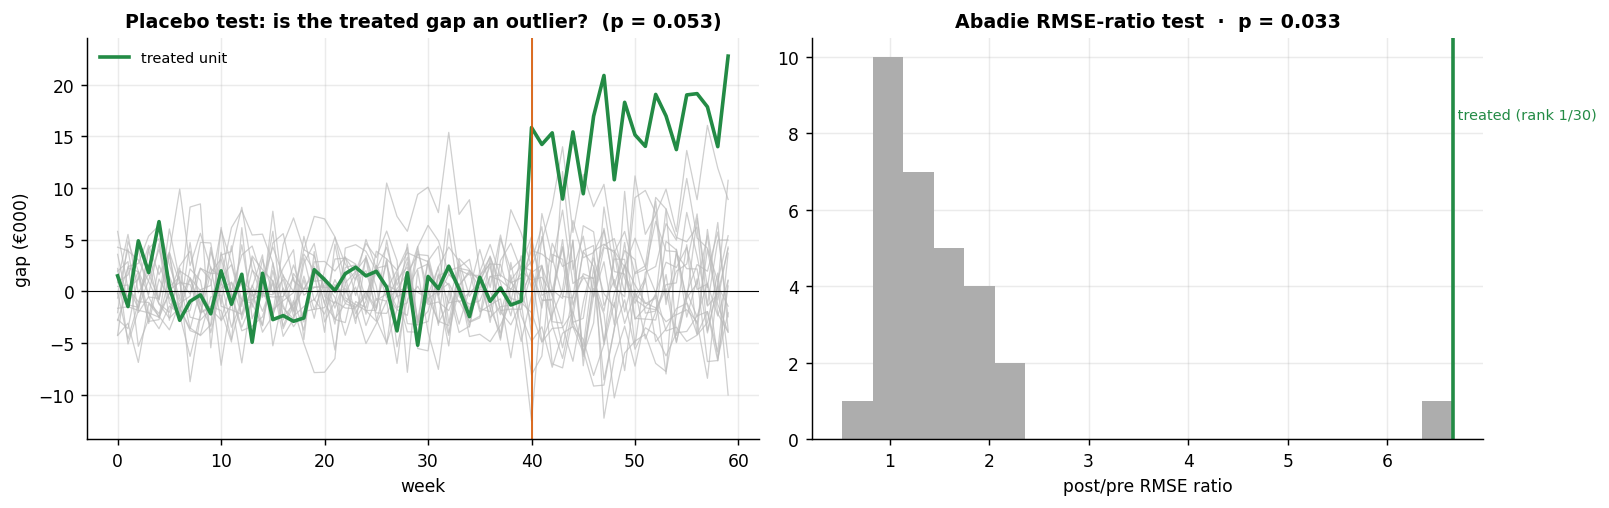

In [10]:
# pre_rmse=None -> use the treated unit's own SLSQP pre-RMSE as the Abadie filter reference (same
# fitter as the placebos; passing the Bayesian sc["pre_rmse"] would mix fitters).
placebo_gaps, real_gap, p_space = est.placebo_in_space(sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=5.0)

# RMSE-ratio test statistic for every unit (treated + all donors)
def rmse_ratio(gap):
    pre_r = np.sqrt(np.mean(gap[pre]**2)); post_r = np.sqrt(np.mean(gap[post]**2))
    return post_r / max(pre_r, 1e-9)
ratios = []
for j in range(sales.shape[0]):
    others = np.delete(np.arange(sales.shape[0]), [treated_idx, j])   # exclude the treated unit too (its post-period is contaminated; mirrors placebo_in_space)
    gap, _ = est.sc_effect_slsqp(sales[j], sales[others], pre, post)
    ratios.append(rmse_ratio(gap))
ratios = np.array(ratios)
treated_ratio = ratios[treated_idx]
p_ratio = (np.sum(ratios >= treated_ratio)) / len(ratios)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.placebo_spaghetti(ax[0], t, placebo_gaps, real_gap, launch, p_space, xlabel="week", ylabel="gap (€000)")
ax[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8); ax[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
ax[1].text(treated_ratio, ax[1].get_ylim()[1]*0.8, f" treated (rank {np.sum(ratios>=treated_ratio)}/{len(ratios)})", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio test  ·  p = {p_ratio:.3f}")
fig.tight_layout()
n_kept = len(placebo_gaps); n_donors = sales.shape[0] - 1
# Is the verdict sensitive to the (somewhat arbitrary) RMSE filter cutoff?
sens = {m: est.placebo_in_space(sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=m)[2] for m in (2.0, 5.0, 20.0)}
print(f"placebo-in-space kept {n_kept}/{n_donors} donors (dropped {n_donors - n_kept}: pre-RMSE > 5x the treated fit)")
print("placebo p vs filter cutoff: " + "  ·  ".join(f"{m:g}x -> p={p:.3f}" for m, p in sens.items()) + "  (tighter filters compare only well-matched placebos and sharpen the test; a loose 20x filter admits poor synthetics and dilutes it)")
print(f"placebo p (gap) = {p_space:.3f} [add-one permutation, treated excluded from placebos]  ·  "
      f"RMSE-ratio p = {p_ratio:.3f} [Abadie rank/N, treated included]  "
      f"(treated ratio {treated_ratio:.1f} vs placebo median {np.median(ratios):.1f}; both rank the treated 1st)")

**Two p-values, reconciled.** The cell prints two significance numbers, and they differ by a few thousandths because they use slightly different bookkeeping. The **raw-gap permutation** p is an *add-one* permutation — the treated market counts as one draw of its own null and is *excluded* from the reference placebos — while **Abadie's RMSE-ratio** p is a rank statistic that keeps the treated market *in* the denominator and divides its post-period fit by its pre-period fit. Both rank the treated market **1st of all units**, so the qualitative verdict is identical. We lead with the **RMSE-ratio**: it is scale-free and penalizes placebos that simply fit badly *everywhere*, so a poor-pre-fit donor can't masquerade as a sharp post-launch jump.

**Placebo-in-time.** A second falsification: pretend the campaign launched *before* it did (a
fake week inside the pre-period). The estimated "effect" should be ≈ 0 — a non-zero fake effect
would mean the method invents lift (anticipation or overfitting).


placebo-in-time avg gap €0.9k  vs  pre-fit RMSE €2.86k (should be ≈ 0, and it is well within the pre-fit noise) — no spurious pre-effect.


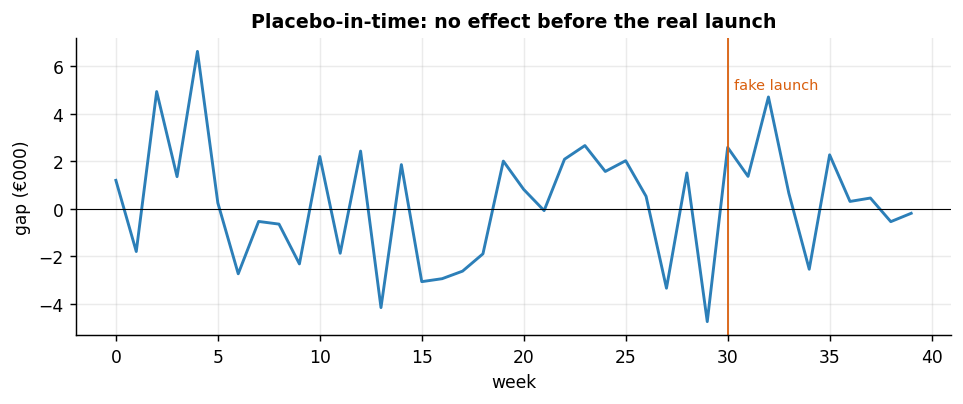

In [11]:
FAKE = launch - 10
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t[:launch], gap_fake, color=plots.BLUE, lw=1.6); ax.axvline(FAKE, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.text(FAKE+0.3, ax.get_ylim()[1]*0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("gap (€000)"); ax.set_title("Placebo-in-time: no effect before the real launch")
fig.tight_layout()
print(f"placebo-in-time avg gap €{fake_effect:.1f}k  vs  pre-fit RMSE €{sc['pre_rmse']:.2f}k "
      f"(should be ≈ 0, and it is well within the pre-fit noise) — no spurious pre-effect.")

**Spillover — stress-testing the one assumption the placebos cannot touch.** The assumption table
in §3 was honest that placebo-in-space *cannot* detect spillover: if the campaign leaks into donor
markets, every placebo refit is contaminated in exactly the same way, so nothing looks unusual. But
the simulator can do what no real dataset can — rerun the same world with spillover *planted*.
Below, a fraction $\varphi$ of the true lift $\Delta_t$ leaks into five "neighbouring" donor
markets ($Y_{jt} \mathrel{+}= \varphi\,\Delta_t$ for $j$ in the neighbour set) and we refit.
First-order prediction *before* running it: the contaminated donors rise, so the synthetic
counterfactual rises, so the measured gap **shrinks** by roughly the spilled weight,

$$\text{bias} \;\approx\; -\,\varphi \sum_{j \in \text{neighbours}} w_j \;\times\; \text{lift},$$

i.e. spillover makes synthetic control **under-state** a real campaign — attenuation toward "no
effect", the opposite of the false-positive failure most people fear.

In [12]:
# Spillover stress test: leak a fraction phi of the true lift into 5 "neighbour" donors, refit,
# and watch the direction of the bias. Same deterministic SLSQP fitter as the LOO check — no MCMC,
# so the whole sweep costs milliseconds; FAST just uses a coarser phi grid.
phis = [0.0, 0.25, 0.5] if FAST else [0.0, 0.1, 0.25, 0.5]
neigh = list(range(5))                       # the 5 "neighbouring" donors (first five in the pool)
rows_sp = []
for phi in phis:
    d_sp = donors.copy(); d_sp[neigh] += phi * true_effect      # the campaign leaks next door
    g_sp, w_sp = est.sc_effect_slsqp(y_tr, d_sp, pre, post)
    rows_sp.append({"phi": phi, "est_total_k": g_sp[post].sum(),
                    "weight_on_neighbours": w_sp[neigh].sum()})
sp = pd.DataFrame(rows_sp)
print(sp.round(2).to_string(index=False), f"   (true total €{true_total:.0f}k)")
base, w0 = sp.est_total_k.iloc[0], sp.weight_on_neighbours.iloc[0]
meas = sp.est_total_k.iloc[-1] - base
pred = -phis[-1] * w0 * base                 # first-order: -phi x (weight on spilled donors) x lift
print(f"attenuation at phi={phis[-1]}: measured €{meas:+.0f}k vs first-order prediction "
      f"-phi·(Σ neighbour weights)·lift = €{pred:+.0f}k")
# the design fix promised in the §3 table, executed once: EXCLUDE the suspect neighbours and refit
d_sp = donors.copy(); d_sp[neigh] += phis[-1] * true_effect
keep = [k for k in range(donors.shape[0]) if k not in neigh]
g_ex, _ = est.sc_effect_slsqp(y_tr, d_sp[keep], pre, post)
print(f"excluding the 5 neighbours at phi={phis[-1]} restores the estimate to €{g_ex[post].sum():.0f}k "
      f"(contaminated pool: €{sp.est_total_k.iloc[-1]:.0f}k; clean pool: €{base:.0f}k)")
print("Read-out: spillover into donors raises the synthetic, so SC UNDER-states the")
print("lift — attenuation, not inflation. Conservative for a GO call, but it can")
print("turn a true GO into a NO-GO. And because no placebo can flag it, the fix is")
print("DESIGN, not statistics: exclude adjacent / media-overlapping donors up")
print("front — as just shown, a clean-but-smaller pool beats a bigger contaminated one.")

 phi  est_total_k  weight_on_neighbours
0.00       317.74                  0.15
0.25       304.75                  0.15
0.50       291.75                  0.15    (true total €339k)
attenuation at phi=0.5: measured €-26k vs first-order prediction -phi·(Σ neighbour weights)·lift = €-24k
excluding the 5 neighbours at phi=0.5 restores the estimate to €311k (contaminated pool: €292k; clean pool: €318k)
Read-out: spillover into donors raises the synthetic, so SC UNDER-states the
lift — attenuation, not inflation. Conservative for a GO call, but it can
turn a true GO into a NO-GO. And because no placebo can flag it, the fix is
DESIGN, not statistics: exclude adjacent / media-overlapping donors up
front — as just shown, a clean-but-smaller pool beats a bigger contaminated one.


---
# Depth C · The euro rollout decision & sensitivity

Pull it together into the number a VP signs off on, and pressure-test how the call moves with
the **launch-timing** assumption (did we mis-date the campaign?) and the **donor pool**.


{
  "true_total": 339.48,
  "estimated_total": 305.28,
  "ci90": [
    272.42,
    341.54
  ],
  "pre_rmse": 2.86,
  "p_space": 0.05,
  "p_rmse_ratio": 0.03,
  "placebo_in_time": 0.9,
  "P_lift_gt_cost": 0.59,
  "decision": "TEST FURTHER",
  "eff_donors": 14.68
}


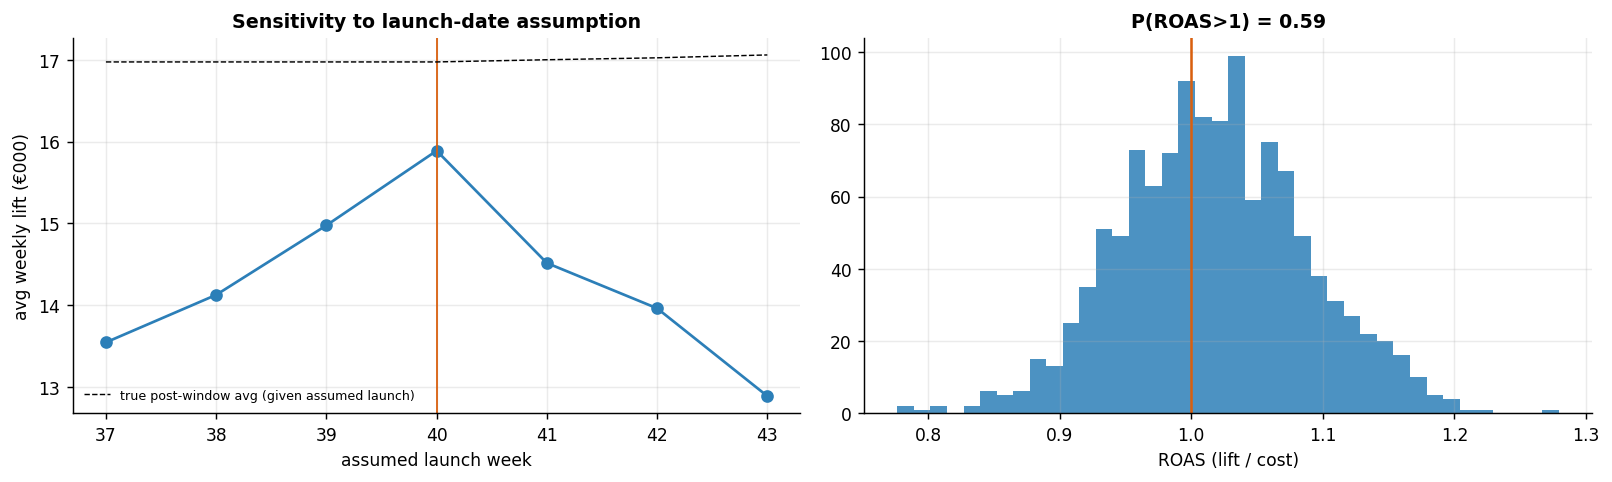

In [13]:
# sensitivity to assumed launch week (±3): does the estimated lift stay stable?
launch_grid = range(launch - 3, launch + 4)
lifts = []
for L in launch_grid:
    g, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, W))
    lifts.append(g[L:].mean())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(list(launch_grid), lifts, color=plots.BLUE, marker="o"); ax[0].axvline(launch, color=plots.ORANGE, lw=1)
# L-dependent benchmark: mis-dating folds no-effect weeks into the post window, so the true
# post-window average changes with the assumed launch L.
true_bench = [true_effect[max(L, launch):].mean() for L in launch_grid]
ax[0].plot(list(launch_grid), true_bench, color="k", ls="--", lw=0.8, label="true post-window avg (given assumed launch)")
ax[0].legend(frameon=False, fontsize=7); ax[0].set_xlabel("assumed launch week")
ax[0].set_ylabel("avg weekly lift (€000)"); ax[0].set_title("Sensitivity to launch-date assumption")
# ROAS curve (revenue per euro spent; break-even at 1) — distinct from go_no_go's ROI = net/cost
roas = total_post / CAMPAIGN_COST
ax[1].hist(roas, bins=40, color=plots.BLUE, alpha=0.85); ax[1].axvline(1.0, color=plots.ORANGE, lw=1.4)
ax[1].set_xlabel("ROAS (lift / cost)"); ax[1].set_title(f"P(ROAS>1) = {(roas>1).mean():.2f}")
fig.tight_layout()
result = {"true_total": true_total, "estimated_total": float(total_post.mean()),
          "ci90": [float(np.quantile(total_post,0.05)), float(np.quantile(total_post,0.95))],
          "pre_rmse": sc["pre_rmse"], "p_space": p_space, "p_rmse_ratio": p_ratio,
          "placebo_in_time": fake_effect, "P_lift_gt_cost": decision["P_value_gt_cost"],
          "decision": decision["decision"], "eff_donors": float(eff_n)}
print(json.dumps(_round(result), indent=2))

### The one-paragraph decision

> The campaign drove a **real** incremental lift: the synthetic tracks the treated market closely
> before launch (low pre-RMSE, pre-gap ≈ 0), spreads its weight across ~15 effective donors (no single
> market dominates), and it is robust to dropping any single donor (leave-one-out stays close to the
> same-fitter baseline). Nudging the *assumed* launch date does shift the estimate — but that is
> mechanical, not fragility: mis-dating folds no-effect weeks into the post window and dilutes the
> average lift, so the peak at the true launch week is itself a diagnostic. The post gap is an outlier on both the raw-gap and the scale-free RMSE-ratio
> **placebo permutation** tests, and the time placebo shows no spurious pre-effect — that permutation
> test is the calibrated evidence the effect is real. The euro call is deliberately cautious: the
> point estimate carries meaningful seed-to-seed variance (this panel lands ~10% below truth; across
> panels the mean bias is small (single digits to low-teens %) but the variance is *large*), and the multi-seed check shows the
> **total-lift interval is optimistic** — so we do **not** let a single posterior interval authorise a
> national rollout. Against the €300k spend the effect sits near break-even: **"promising, confirm with
> a second geo test," not "scale nationally today."** The effect is clearly real; whether it clears
> *this* cost is the close call — and one an optimistic interval should make us *more*, not less, cautious about.